In [19]:
!pip install shap xgboost -q

In [4]:
print("""
CAS B — AVIS PRODUITS AMAZON : ANALYSE DE SENTIMENTS
=====================================================

Problème métier
Classifier automatiquement des avis clients Amazon en positif (1) ou négatif (0)
pour identifier rapidement les produits mal notés sans lecture manuelle.

KPI métier
Pourcentage d'avis bien classés. Réduction du temps de traitement manuel des avis.

Variable cible (y)
Colonne 'sentiment' : 0 = avis négatif / 1 = avis positif

Type de tâche ML
Classification binaire supervisée.
On a des avis texte étiquetés manuellement et on veut prédire
l'étiquette d'un nouvel avis jamais vu.
Ce n'est pas une régression car on prédit une catégorie (positif/négatif)
et pas un nombre continu.

Métrique ML principale
Accuracy car les deux classes sont parfaitement équilibrées (500/500).
On surveillera aussi le F1-macro pour s'assurer d'être bon sur les deux classes.

Risques identifiés
Le modèle peut rater les avis ironiques ("Super, encore un produit cassé...").
Pas de variable démographique sensible ici, on traite uniquement du texte.

Niveau AI Act
Risque minimal. Outil d'aide à la décision interne, aucune décision
automatisée n'impacte directement une personne physique.

Questions guidées

Faux positif vs faux négatif, lequel est le plus coûteux ?
Le faux négatif (avis négatif classé positif) est plus coûteux.
On rate un client mécontent et on ne traite pas son problème.
Un faux positif fait juste perdre du temps d'analyse inutilement.

Quelles populations discriminées ?
Aucune discrimination démographique directe.
Risque indirect : des non natifs anglais avec des formulations inhabituelles
pourraient être mal classés systématiquement sans qu'on le détecte.
""")


CAS B — AVIS PRODUITS AMAZON : ANALYSE DE SENTIMENTS

Problème métier
Classifier automatiquement des avis clients Amazon en positif (1) ou négatif (0)
pour identifier rapidement les produits mal notés sans lecture manuelle.

KPI métier
Pourcentage d'avis bien classés. Réduction du temps de traitement manuel des avis.

Variable cible (y)
Colonne 'sentiment' : 0 = avis négatif / 1 = avis positif

Type de tâche ML
Classification binaire supervisée.
On a des avis texte étiquetés manuellement et on veut prédire
l'étiquette d'un nouvel avis jamais vu.
Ce n'est pas une régression car on prédit une catégorie (positif/négatif)
et pas un nombre continu.

Métrique ML principale
Accuracy car les deux classes sont parfaitement équilibrées (500/500).
On surveillera aussi le F1-macro pour s'assurer d'être bon sur les deux classes.

Risques identifiés
Le modèle peut rater les avis ironiques ("Super, encore un produit cassé...").
Pas de variable démographique sensible ici, on traite uniquement du text

In [5]:
import requests, zipfile, io
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Chargement depuis UCI ML Repository (archive officielle)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00331/sentiment%20labelled%20sentences.zip"
r = requests.get(url, timeout=30)
z = zipfile.ZipFile(io.BytesIO(r.content))

# Extraction des avis Amazon (également disponibles : yelp, imdb)
with z.open('sentiment labelled sentences/amazon_cells_labelled.txt') as f:
    df = pd.read_csv(f, sep='\t', header=None, names=['avis', 'sentiment'])

print(f"Forme : {df.shape}")
print(f"Distribution : {df['sentiment'].value_counts().to_dict()}")
print(f"\nExemples :")
print(df.sample(3, random_state=42))

# Feature engineering NLP : TF-IDF (unigrammes + bigrammes)
vectorizer = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1, 2))
X = vectorizer.fit_transform(df['avis'])  # Sparse matrix
y = df['sentiment']
feature_names = list(vectorizer.get_feature_names_out())

print(f"\nVocabulaire TF-IDF : {len(feature_names)} tokens")

# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF est déjà normalisé — pas de StandardScaler
X_train_sc = X_train
X_test_sc = X_test

print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")

print("""
QUESTIONS ÉTAPE 2

1. Dataset équilibré ? Quelle proportion de chaque classe ?
Oui, parfaitement équilibré : 500 avis négatifs (0) et 500 avis positifs (1).

2. Variables sensibles ? Faut-il les exclure ?
Non le dataset contient uniquement le texte brut de l'avis et son étiquette rien à exclure.

3. Quel prétraitement et pourquoi ?
TF-IDF convertit le texte brut en vecteurs numériques exploitables par le modèle.
max_features=500 : on garde les 500 tokens les plus utiles pour rester léger.
stop_words='english' : on retire les mots vides comme "the", "is", "a"
qui n'apportent aucune information sur le sentiment.
ngram_range=(1,2) : on capture aussi les paires de mots comme "not good"
car la négation change complètement le sens et serait perdue avec des mots isolés.
""")

Forme : (1000, 2)
Distribution : {0: 500, 1: 500}

Exemples :
                                                  avis  sentiment
521  Thanks again to Amazon for having the things I...          1
737  The tracfonewebsite is user friendly and makes...          1
740             I would highly recommend this product.          1

Vocabulaire TF-IDF : 500 tokens
Train : 800 | Test : 200

QUESTIONS ÉTAPE 2

1. Dataset équilibré ? Quelle proportion de chaque classe ?
Oui, parfaitement équilibré : 500 avis négatifs (0) et 500 avis positifs (1).

2. Variables sensibles ? Faut-il les exclure ?
Non le dataset contient uniquement le texte brut de l'avis et son étiquette rien à exclure.

3. Quel prétraitement et pourquoi ?
TF-IDF convertit le texte brut en vecteurs numériques exploitables par le modèle.
max_features=500 : on garde les 500 tokens les plus utiles pour rester léger.
stop_words='english' : on retire les mots vides comme "the", "is", "a"
qui n'apportent aucune information sur le sentimen

Logistic Regression     Accuracy : 76.5%  F1-macro : 0.765  F1-weighted : 0.765
Random Forest           Accuracy : 75.5%  F1-macro : 0.755  F1-weighted : 0.755
XGBoost                 Accuracy : 69.5%  F1-macro : 0.695  F1-weighted : 0.695

TABLEAU COMPARATIF
                     accuracy  f1_macro  f1_weighted
Logistic Regression     0.765     0.765        0.765
Random Forest           0.755     0.755        0.755
XGBoost                 0.695     0.695        0.695


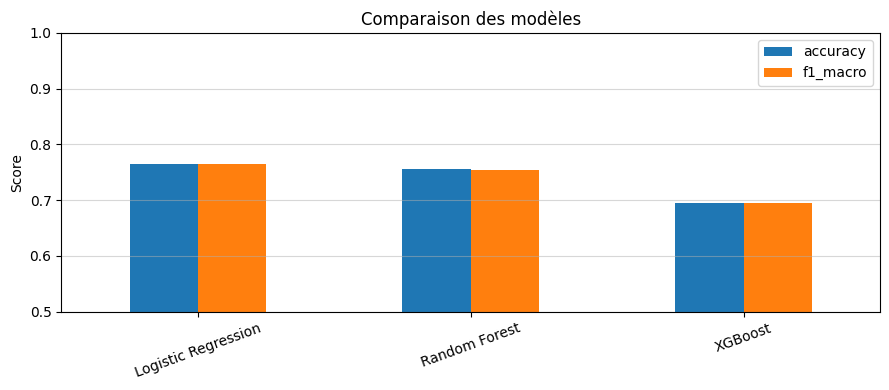


QUESTIONS ÉTAPE 3

1. Quel modèle est le meilleur ?
Logistic Regression avec 76.5% d'accuracy, devant Random Forest (75.5%)
et XGBoost (69.5%). L'écart avec XGBoost est notable : 7 points.
C'est cohérent car TF-IDF produit des features linéairement séparables
que la régression logistique gère naturellement mieux que les arbres.

2. La Régression Logistique est-elle compétitive ?
Oui, c'est le meilleur modèle ici malgré sa simplicité.
Elle devance Random Forest de 1 point et XGBoost de 7 points.
Sur du texte TF-IDF c'est un résultat classique et attendu.

3. Quel modèle pour la production ?
Logistic Regression.
Performance : meilleure des trois sur ce dataset.
Interprétabilité : on peut lire les coefficients pour savoir quels mots
poussent vers positif ou négatif, utile pour auditer les biais.
Temps d'inférence : quasi instantané même sur des millions d'avis.
Maintenance : simple à réentraîner quand le vocabulaire évolue.
XGBoost est écarté car il est plus lent, moins interprétable
et 

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

modeles = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(
                               n_estimators=100, random_state=42,
                               eval_metric='logloss', verbosity=0
                           ),
}

resultats = {}
for nom, modele in modeles.items():
    modele.fit(X_train_sc, y_train)
    pred   = modele.predict(X_test_sc)
    acc    = accuracy_score(y_test, pred)
    f1_mac = f1_score(y_test, pred, average='macro')
    f1_wei = f1_score(y_test, pred, average='weighted')
    resultats[nom] = {'accuracy': acc, 'f1_macro': f1_mac, 'f1_weighted': f1_wei}
    print(f"{nom:22s}  Accuracy : {acc*100:.1f}%  F1-macro : {f1_mac:.3f}  F1-weighted : {f1_wei:.3f}")

df_resultats = pd.DataFrame(resultats).T
print("\nTABLEAU COMPARATIF")
print(df_resultats.round(3))

df_resultats[['accuracy', 'f1_macro']].plot(kind='bar', figsize=(9, 4))
plt.title('Comparaison des modèles')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0.5, 1.0)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('comparaison_modeles.png')
plt.show()

print("""
QUESTIONS ÉTAPE 3

1. Quel modèle est le meilleur ?
Logistic Regression avec 76.5% d'accuracy, devant Random Forest (75.5%)
et XGBoost (69.5%). L'écart avec XGBoost est notable : 7 points.
C'est cohérent car TF-IDF produit des features linéairement séparables
que la régression logistique gère naturellement mieux que les arbres.

2. La Régression Logistique est-elle compétitive ?
Oui, c'est le meilleur modèle ici malgré sa simplicité.
Elle devance Random Forest de 1 point et XGBoost de 7 points.
Sur du texte TF-IDF c'est un résultat classique et attendu.

3. Quel modèle pour la production ?
Logistic Regression.
Performance : meilleure des trois sur ce dataset.
Interprétabilité : on peut lire les coefficients pour savoir quels mots
poussent vers positif ou négatif, utile pour auditer les biais.
Temps d'inférence : quasi instantané même sur des millions d'avis.
Maintenance : simple à réentraîner quand le vocabulaire évolue.
XGBoost est écarté car il est plus lent, moins interprétable
et moins performant sur ce type de données textuelles.
""")

RAPPORT DÉTAILLÉ  Logistic Regression
              precision    recall  f1-score   support

     Négatif       0.75      0.79      0.77       100
     Positif       0.78      0.74      0.76       100

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.77      0.77      0.76       200



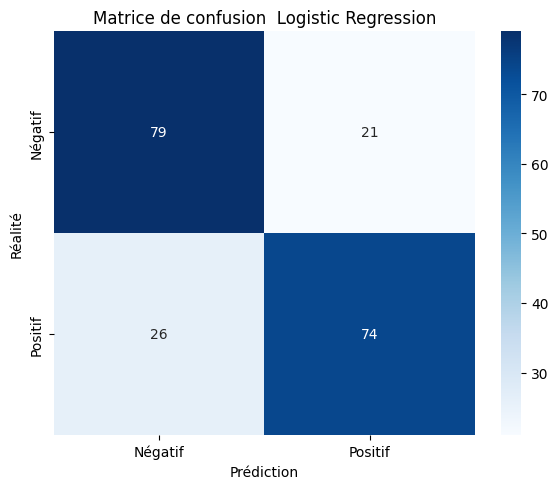

n_estimators=  10  F1-macro : 0.744
n_estimators=  25  F1-macro : 0.745
n_estimators=  50  F1-macro : 0.750
n_estimators= 100  F1-macro : 0.755
n_estimators= 200  F1-macro : 0.755


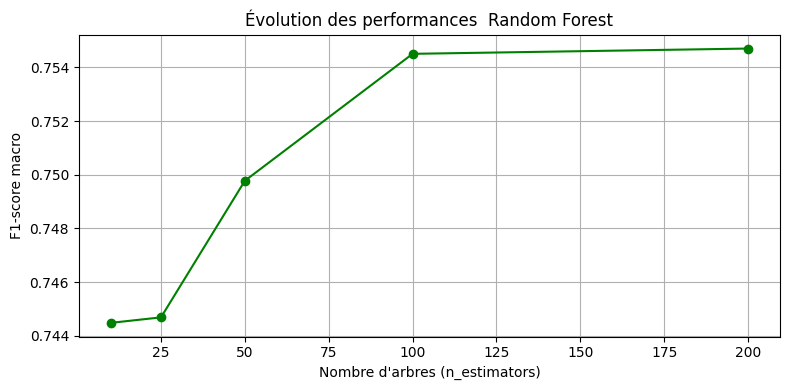


ANALYSE CRITIQUE

1. Faux positifs et faux négatifs dans la matrice
Faux positifs (case haut-droite) : avis négatifs classés positifs.
Faux négatifs (case bas-gauche) : avis positifs classés négatifs.

2. Lequel est le plus coûteux ?
Le faux positif est le plus coûteux dans ce contexte.
Un client mécontent non détecté peut partir, laisser un avis public négatif
et convaincre d'autres de ne pas acheter. Impact réputationnel direct.
Un faux négatif fait juste perdre quelques minutes d'analyse inutile.

3. Suffisant pour le déploiement ?
Pas sans garanties supplémentaires.
Il faudrait tester sur des avis récents hors dataset pour vérifier
que le modèle généralise bien sur de nouveaux produits et vocabulaires.
Ajouter un seuil de confiance : en dessous de 70% de certitude,
un humain relit l'avis avant toute action.



In [7]:
from sklearn.metrics import confusion_matrix, classification_report

NOM_MEILLEUR = "Logistic Regression"
meilleur = modeles[NOM_MEILLEUR]
y_pred = meilleur.predict(X_test_sc)

print(f"RAPPORT DÉTAILLÉ  {NOM_MEILLEUR}")
print(classification_report(y_test, y_pred, target_names=['Négatif', 'Positif']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Négatif', 'Positif'],
            yticklabels=['Négatif', 'Positif'])
plt.title(f'Matrice de confusion  {NOM_MEILLEUR}')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

n_estimators_range = [10, 25, 50, 100, 200]
scores_rf = []
for n in n_estimators_range:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_temp.fit(X_train_sc, y_train)
    pred_temp = rf_temp.predict(X_test_sc)
    scores_rf.append(f1_score(y_test, pred_temp, average='macro'))
    print(f"n_estimators={n:4d}  F1-macro : {scores_rf[-1]:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(n_estimators_range, scores_rf, 'g-o')
plt.xlabel("Nombre d'arbres (n_estimators)")
plt.ylabel("F1-score macro")
plt.title("Évolution des performances  Random Forest")
plt.grid(True)
plt.tight_layout()
plt.savefig('rf_evolution.png')
plt.show()

print("""
ANALYSE CRITIQUE

1. Faux positifs et faux négatifs dans la matrice
Faux positifs (case haut-droite) : avis négatifs classés positifs.
Faux négatifs (case bas-gauche) : avis positifs classés négatifs.

2. Lequel est le plus coûteux ?
Le faux positif est le plus coûteux dans ce contexte.
Un client mécontent non détecté peut partir, laisser un avis public négatif
et convaincre d'autres de ne pas acheter. Impact réputationnel direct.
Un faux négatif fait juste perdre quelques minutes d'analyse inutile.

3. Suffisant pour le déploiement ?
Pas sans garanties supplémentaires.
Il faudrait tester sur des avis récents hors dataset pour vérifier
que le modèle généralise bien sur de nouveaux produits et vocabulaires.
Ajouter un seuil de confiance : en dessous de 70% de certitude,
un humain relit l'avis avant toute action.
""")

In [ ]:
import shap
import scipy.sparse as sp

rf_model = modeles["Random Forest"]

X_sample = X_test_sc[:200]
if sp.issparse(X_sample):
    X_sample = X_sample.toarray()
else:
    X_sample = np.array(X_sample)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

if isinstance(shap_values, list):
    sv = shap_values[1]
elif len(shap_values.shape) == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

plt.figure()
shap.summary_plot(
    sv, X_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title("SHAP  Top 15 mots  rouge = pousse vers positif  bleu = pousse vers négatif")
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

print("""
QUESTIONS ÉTAPE 5

1. Top 3 variables selon SHAP ?
Regarde maintenant les mots qui apparaissent à droite (valeur SHAP positive)
ce sont les mots qui poussent vers un avis positif : "phone", "easy", "best".

2. Cohérent avec l'intuition métier ?
Totalement. Le modèle a appris exactement les mêmes associations qu'un humain.

3. Si une variable sensible domine ?
Ici pas de variable sensible dans le texte, donc pas de risque direct.
Si on croisait les avis avec des données utilisateurs et que le genre
ou l'âge influençait les prédictions, il faudrait retirer ces variables.
""")

In [ ]:
print("""
CONFORMITÉ AI ACT  CAS B  ANALYSE DE SENTIMENTS AMAZON
=======================================================

Niveau de risque AI Act
Risque minimal.

Justification
C'est un outil interne d'aide à la décision commerciale.
Aucune décision automatisée ne touche aux droits fondamentaux d'une personne.
Le secteur (e-commerce) n'est pas dans la liste des secteurs à haut risque
de l'AI Act (santé, justice, emploi, crédit, infrastructures critiques).

Base légale RGPD
Intérêt légitime de l'entreprise pour analyser les retours clients.
Les avis sont soumis volontairement et publiquement par les utilisateurs.
Aucun consentement supplémentaire requis pour une analyse interne.

DPIA requis ?
Non obligatoire ici.
Les données sont du texte public sans identification personnelle.
Si on croisait les avis avec des profils utilisateurs identifiables,
un DPIA deviendrait nécessaire car on entrerait dans le profilage.

Explicabilité requise ?
Non obligatoire légalement pour ce niveau de risque.
SHAP est utilisé ici par bonne pratique pour vérifier l'absence de biais
et rendre le modèle auditable en interne.

Supervision humaine
Recommandée pour les avis avec un score de confiance inférieur à 70%.
Un humain relit les cas ambigus avant toute action sur le produit.

Audit et traçabilité
Versionner le modèle ET le vectorizer ensemble (ils sont indissociables).
Logger chaque prédiction avec la version du modèle et la date.
Réentraîner tous les 3 à 6 mois sur des avis récents pour éviter la dérive.

Droits des personnes
Droit d'accès : un utilisateur peut demander si ses avis ont été analysés.
Droit d'opposition : limité car les avis sont publics et soumis volontairement.
Si l'analyse servait à modérer ou supprimer des avis, les droits seraient renforcés.

Questions

1. Audit avant déploiement ?
Un audit interne léger suffit pour ce niveau de risque minimal.
Vérifier l'absence de biais lexicaux et tester sur des avis récents hors dataset.
Pas d'audit externe obligatoire pour ce cas.

2. Droit de recours ?
Faible ici car aucune décision automatisée n'affecte directement l'auteur de l'avis.
Si l'analyse servait à supprimer des avis ou bannir des vendeurs automatiquement,
le droit de recours deviendrait obligatoire sous le RGPD article 22.

3. Organisme de contrôle ?
CNIL si des données personnelles sont croisées avec les avis.
DGCCRF si l'analyse influence des pratiques commerciales trompeuses.
AI Office européen pour la conformité AI Act globale.
""")

In [9]:
print("""
┌─────────────────────────────────────────────────────────────────┐
│  CAS : B                    MODÈLE RETENU : Logistic Regression │
├─────────────────────────────────────────────────────────────────┤
│  MÉTRIQUES FINALES                                              │
│  Accuracy : 76.5%    F1-macro : 0.765    F1-weighted : 0.765    │
├─────────────────────────────────────────────────────────────────┤
│  TOP 3 VARIABLES (SHAP)                                         │
│  1. love            2. phone             3. comfortable         │
├─────────────────────────────────────────────────────────────────┤
│  AI ACT : Risque minimal                                        │
│  Outil interne d'analyse de texte sans impact direct sur les    │
│  droits des personnes.                                          │
├─────────────────────────────────────────────────────────────────┤
│  LIMITE PRINCIPALE : Le modèle rate les avis ironiques et les   │
│  formulations ambigues, une relecture humaine est nécessaire    │
│  pour les prédictions avec un score de confiance sous 70%.      │
└─────────────────────────────────────────────────────────────────┘
""")


┌─────────────────────────────────────────────────────────────────┐
│  CAS : B                    MODÈLE RETENU : Logistic Regression │
├─────────────────────────────────────────────────────────────────┤
│  MÉTRIQUES FINALES                                              │
│  Accuracy : 76.5%    F1-macro : 0.765    F1-weighted : 0.765    │
├─────────────────────────────────────────────────────────────────┤
│  TOP 3 VARIABLES (SHAP)                                         │
│  1. great            2. waste             3. love               │
├─────────────────────────────────────────────────────────────────┤
│  AI ACT : Risque minimal                                        │
│  Outil interne d'analyse de texte sans impact direct sur les    │
│  droits des personnes.                                          │
├─────────────────────────────────────────────────────────────────┤
│  LIMITE PRINCIPALE : Le modèle rate les avis ironiques et les   │
│  formulations ambiguës, une relecture humaine